Import modules, define network and apply transformations

In [1]:
import torch
from torchvision.datasets import Flowers102
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, ConcatDataset
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

class FlowersNetwork(nn.Module):
    def __init__(self, in_channels, out_features, activation_function = F.relu):
        super(FlowersNetwork, self).__init__()

        # Block 1
        self.conv1_1 = nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=7, padding=3)
        self.conv1_2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=7, padding=3)  
        self.bn1 = nn.BatchNorm2d(32)

        # Block 2
        self.conv2_1 = nn.Conv2d(32, 64, kernel_size=5, padding=2)
        self.conv2_2 = nn.Conv2d(64, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(64)

        # Block 3
        self.conv3_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.conv3_3 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Block 4
        self.conv4_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv4_3 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        # Block 5
        self.conv5_1 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.conv5_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv5_3 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout1 = nn.Dropout(p=0.75)
        self.dropout2 = nn.Dropout(p=0.5)


        self.fc1 = nn.Linear(512, 1024)
        self.fc2 = nn.Linear(1024, out_features)

        self.activation_function = activation_function

    def forward(self, x):
        # Block 1
        x = self.activation_function(self.conv1_1(x))
        x = self.pool(self.activation_function(self.bn1(self.conv1_2(x))))

        # Block 2
        x = self.activation_function(self.conv2_1(x))
        x = self.pool(self.activation_function(self.bn2(self.conv2_2(x))))

        # Block 3
        x = self.activation_function(self.conv3_1(x))
        x = self.activation_function(self.conv3_2(x))
        x = self.pool(self.activation_function(self.bn3(self.conv3_3(x))))

        # Block 4
        x = self.activation_function(self.conv4_1(x))
        x = self.activation_function(self.conv4_2(x))
        x = self.pool(self.activation_function(self.bn4(self.conv4_3(x))))

        # Block 5
        x = self.activation_function(self.conv5_1(x))
        x = self.activation_function(self.conv5_2(x))
        x = self.pool(self.activation_function(self.bn5(self.conv5_3(x))))
        
        # Fully connected layers
        x = self.global_avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout1(self.activation_function(self.fc1(x)))
        x = self.dropout2(self.fc2(x))
        return x

# Set image dimensions
imageWidth = 224
imageHeight = 224

# Define batch size
batch_size = 32

# Calculate mean and standard deviation of the dataset for normalisation
flowersTransform_no_norm = transforms.Compose([
    transforms.Resize((imageWidth, imageHeight)),
    transforms.ToTensor()
])

flowersTrain_no_norm = Flowers102(root="./data", split="train", download=True, transform=flowersTransform_no_norm)
train_no_norm_loader = DataLoader(flowersTrain_no_norm, batch_size=batch_size, shuffle=False)

mean = 0.
std = 0.
total_samples = 0

for images, _ in train_no_norm_loader:
    batch_samples = images.size(0)
    images = images.view(batch_samples, images.size(1), -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total_samples += batch_samples

mean /= total_samples
std /= total_samples

# Apply transformations to dataset
trainingTransform = transforms.Compose([
    transforms.Resize((imageWidth, imageHeight)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

testingTransform = transforms.Compose([
    transforms.Resize((imageWidth, imageHeight)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Combine augmented and original training sets to make 1 large training set
flowersAugmented = Flowers102(root = "./data", split = "train", download=True, transform = trainingTransform)
flowersNormal = Flowers102(root = "./data", split = "train", download=True, transform = testingTransform)
flowersTrain = ConcatDataset([flowersAugmented, flowersNormal])

flowersValidate = Flowers102(root = "./data", split = "val", download=True, transform = testingTransform)
flowersTest = Flowers102(root = "./data", split = "test", download=True, transform = testingTransform)

# Move model onto GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create DataLoaders for batch usage
train_loader = DataLoader(flowersTrain, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(flowersValidate, batch_size=batch_size, shuffle=False)

imageChannels = 3 #R,G,B
imageSize = imageWidth*imageHeight*imageChannels

Initialise classifier, optimiser and loss function. Then train the model, output loss and evaluate accuracy per epoch.

In [2]:
from sklearn.metrics import precision_score, recall_score, f1_score

classifier = FlowersNetwork(in_channels = imageChannels, out_features = 102, activation_function = F.selu)

# Move model to GPU
classifier.to(device)

lossFunction = nn.CrossEntropyLoss()
optimiser = torch.optim.AdamW(classifier.parameters(), lr=0.0001, weight_decay=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.1, patience=5)

epochs = 200
bestLoss = float('inf')
patience = 5
lossTolerance = 1e-4
losses = []
valAccuracies = []
precisions = []
recalls = []
f1Scores = []
for i in range(epochs):
  print(f"-----Epoch {i+1}-----")
  classifier.train()
  epochLoss = 0.0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    predictions = classifier.forward(images)

    loss = lossFunction(predictions, labels)
    epochLoss += loss.item()

    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

  # Validation phase
  classifier.eval()
  val_loss = 0.0
  correct = 0
  total = 0
  all_labels = []
  all_preds = []
  with torch.no_grad():
      for images, labels in val_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = classifier(images)
          val_loss += lossFunction(outputs, labels).item()
          _, predicted = torch.max(outputs, 1)
          correct += (predicted == labels).sum().item()
          total += labels.size(0)
          all_labels.extend(labels.cpu().numpy())
          all_preds.extend(predicted.cpu().numpy())

  val_loss /= len(val_loader)
  val_accuracy = correct / total
  print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")
  valAccuracies.append(val_accuracy)

  precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
  recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
  f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
  print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

  precisions.append(precision)
  recalls.append(recall)
  f1Scores.append(f1)

  scheduler.step(val_loss)

  epochLoss /= len(train_loader)
  losses.append(epochLoss)
  print(f"Epoch Training Loss: {epochLoss:.6f}")

-----Epoch 1-----
Validation Loss: 4.4703, Validation Accuracy: 0.0402
Precision: 0.0070, Recall: 0.0402, F1 Score: 0.0107
Epoch Training Loss: 4.833743
-----Epoch 2-----
Validation Loss: 4.4626, Validation Accuracy: 0.0284
Precision: 0.0136, Recall: 0.0284, F1 Score: 0.0102
Epoch Training Loss: 4.668530
-----Epoch 3-----
Validation Loss: 4.3637, Validation Accuracy: 0.0549
Precision: 0.0238, Recall: 0.0549, F1 Score: 0.0215
Epoch Training Loss: 4.628827
-----Epoch 4-----
Validation Loss: 4.2643, Validation Accuracy: 0.0745
Precision: 0.0408, Recall: 0.0745, F1 Score: 0.0373
Epoch Training Loss: 4.555949
-----Epoch 5-----
Validation Loss: 4.2766, Validation Accuracy: 0.0608
Precision: 0.0348, Recall: 0.0608, F1 Score: 0.0282
Epoch Training Loss: 4.511292
-----Epoch 6-----
Validation Loss: 4.2390, Validation Accuracy: 0.0716
Precision: 0.0295, Recall: 0.0716, F1 Score: 0.0318
Epoch Training Loss: 4.432345
-----Epoch 7-----
Validation Loss: 4.2340, Validation Accuracy: 0.0686
Precision: 

Plot graphs

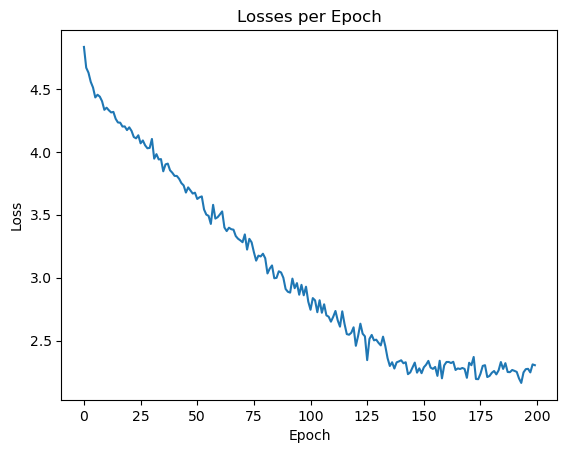

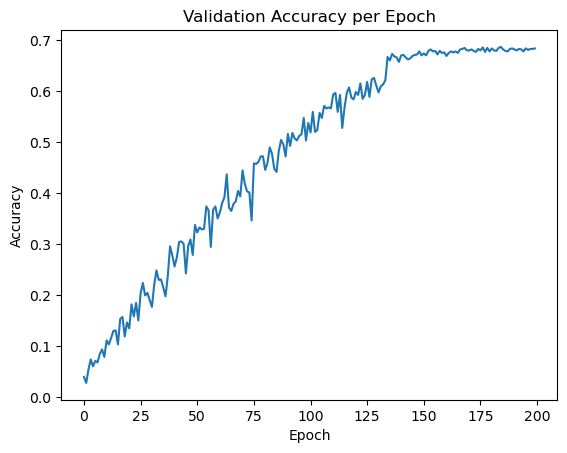

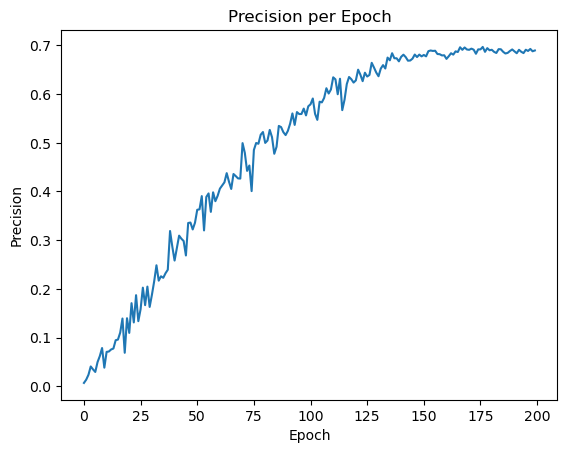

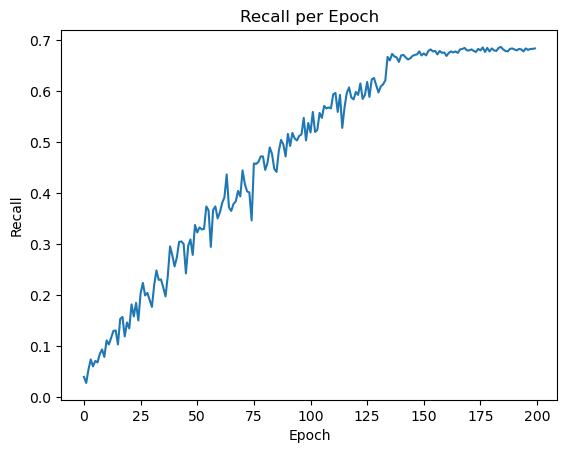

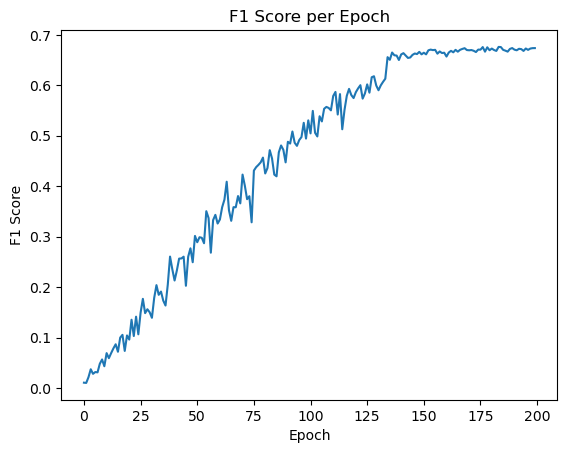

In [3]:
plt.plot(range(len(losses)), losses)
plt.title("Losses per Epoch")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

plt.plot(range(len(valAccuracies)), valAccuracies)
plt.title("Validation Accuracy per Epoch")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

plt.plot(range(len(precisions)), precisions)
plt.title("Precision per Epoch")
plt.ylabel("Precision")
plt.xlabel("Epoch")
plt.show()

plt.plot(range(len(recalls)), recalls)
plt.title("Recall per Epoch")
plt.ylabel("Recall")
plt.xlabel("Epoch")
plt.show()

plt.plot(range(len(f1Scores)), f1Scores)
plt.title("F1 Score per Epoch")
plt.ylabel("F1 Score")
plt.xlabel("Epoch")
plt.show()

Save model

In [7]:
torch.save(classifier.state_dict(), 'SAVEDMODEL.pth')

In [5]:
classifier = FlowersNetwork(in_channels = imageChannels, out_features = 102, activation_function = F.selu)
classifier.to(device)
classifier.load_state_dict(torch.load('SAVEDMODEL.pth'))

<All keys matched successfully>

Calculate model accuracy

In [6]:
classifier.eval()

with torch.no_grad():
  correct = 0
  total = 0
  test_loader = DataLoader(flowersTest, batch_size=1)
  for images, labels in test_loader:
        images = images.to(device)
        predictions = classifier.forward(images)
        _, predictedClass = torch.max(predictions, dim=1)

        total += 1
        if predictedClass.item() == labels.item():
            correct += 1
  accuracy = correct / total
  print(f"Model Accuracy: {accuracy}")

Model Accuracy: 0.6191250609855261


Model's accuracy (on my run): 61.9% - Much better than the previous model.
Major differences in this model include the use of the selu activation function and an increase of dropout in the neural network.
Monitoring training accuracy indicated significant overfitting of the model - reducing this has improved the accuracy of it.
The model is still overfitting however, with a final training accuracy of 97%, so I can try to reduce overfitting again, which should hopefully yield even better results.